In [2]:
import pandas as pd 
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import rasterio

In [3]:
gdf = gpd.read_file(r"C:\Users\ohm\Downloads\Sample Data\India State Boundaries\India_District_Boundary.shp")

In [5]:
raster = rasterio.open(r"C:\Users\ohm\Downloads\Sample Data\rasterdata\india.clipped.tif")

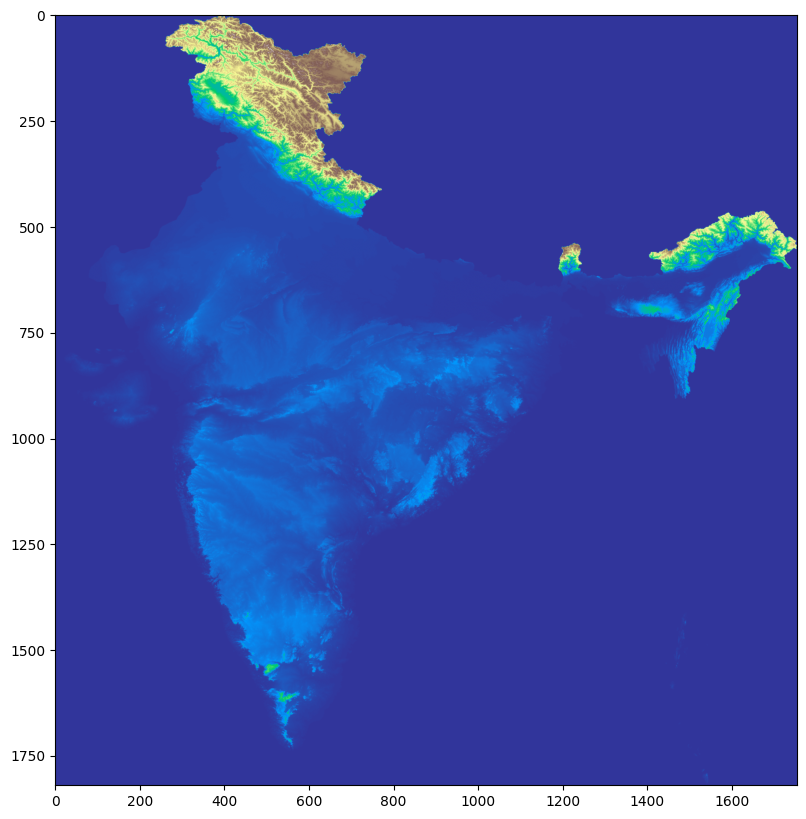

In [12]:
from rasterio.enums import Resampling

band = raster.read(
    1,
    out_shape=(
        raster.height // 20,
        raster.width // 20
    ),
    resampling=Resampling.average
)

plt.figure(figsize=(10,10))
plt.imshow(band, cmap="terrain")
plt.show()

In [13]:
print("Vector CRS:", gdf.crs)
print("Raster CRS:", raster.crs)

Vector CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Raster CRS: EPSG:4326


In [14]:
gdf = gdf.to_crs(raster.crs)

In [15]:
print(gdf.crs)
print(raster.crs)

GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
EPSG:4326


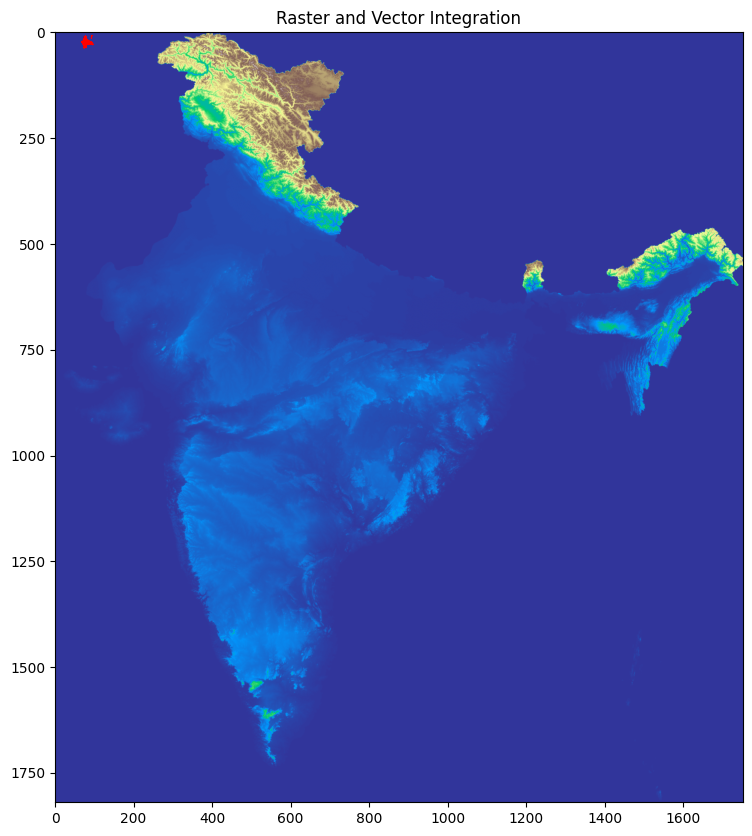

In [17]:
from rasterio.enums import Resampling

band = raster.read(
    1,
    out_shape=(
        raster.height // 20,
        raster.width // 20
    ),
    resampling=Resampling.average
)

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(band, cmap="terrain")

gdf.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=0.5
)

plt.title("Raster and Vector Integration")
plt.show()

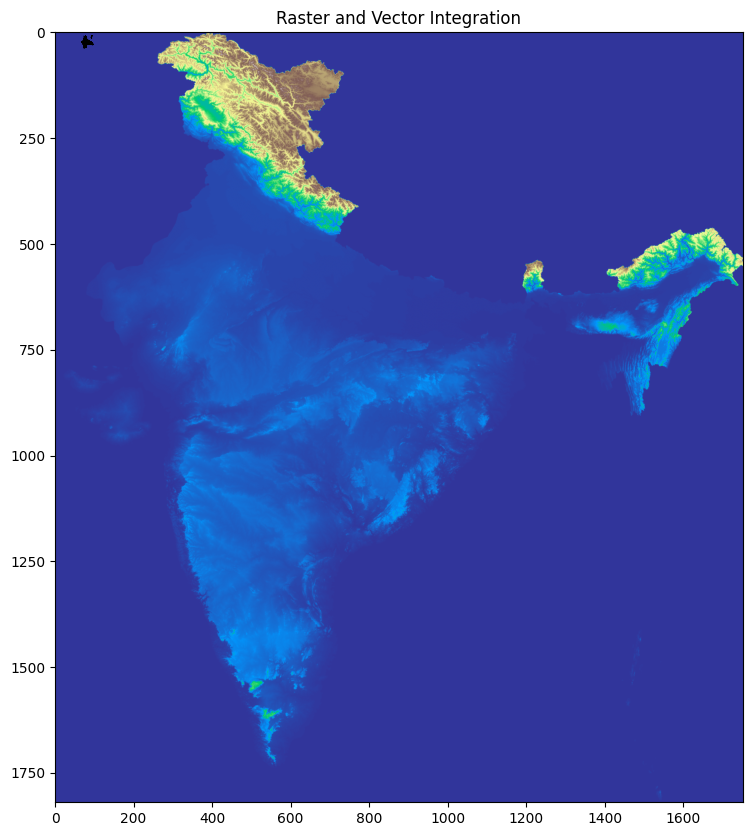

In [18]:
fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(band, cmap="terrain")

gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Raster and Vector Integration")
plt.show()